# 02 - Feature Engineering et Modélisation Baseline

**Projet** : Scoring de Crédit et Prévision de Défauts  
**Auteur** : Shafin Hamjah (Data Engineer)  
**Date** : Janvier 2026

---

## Objectifs de ce notebook

1. **Feature Engineering** : Créer de nouvelles variables prédictives
2. **Préparation des données** : Split temporel et encodage
3. **Modélisation Baseline** : Régression logistique avec SMOTE
4. **Évaluation** : Métriques et visualisations
5. **Analyse temporelle** : Étude préliminaire de la série des défauts

## 0. Configuration et imports

In [125]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score
)
import joblib

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Seed pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chemins
ROOT_DIR = Path('..')
DATA_PATH = ROOT_DIR / 'data' / 'processed' / 'credit_data_cleaned.parquet'
FIGURES_PATH = ROOT_DIR / 'outputs' / 'figures' / '02_modeling'
MODELS_PATH = ROOT_DIR / 'outputs' / 'models'

# Créer les dossiers si nécessaire
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print("Configuration terminée ✓")
print(f"Fichier de données : {DATA_PATH}")

Configuration terminée ✓
Fichier de données : ..\data\processed\credit_data_cleaned.parquet


## 1. Chargement des données nettoyées

In [126]:
# Chargement des données prétraitées
df = pd.read_parquet(DATA_PATH)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nPériode : {df['DATE_MONTH'].min()} à {df['DATE_MONTH'].max()}")

Dimensions : 130,000 lignes × 66 colonnes
Mémoire : 46.37 MB

Période : 2021-01-01 00:00:00 à 2025-12-01 00:00:00


In [127]:
# Rappel de la distribution de la cible
target_dist = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("Distribution TARGET :")
print(f"  0 (Non défaut) : {target_dist[0]:,} ({target_pct[0]:.2f}%)")
print(f"  1 (Défaut)     : {target_dist[1]:,} ({target_pct[1]:.2f}%)")
print(f"\n⚠️ Ratio de déséquilibre : 1:{target_dist[0]/target_dist[1]:.1f}")

Distribution TARGET :
  0 (Non défaut) : 105,820 (81.40%)
  1 (Défaut)     : 24,180 (18.60%)

⚠️ Ratio de déséquilibre : 1:4.4


In [128]:
# Aperçu des colonnes disponibles
print(f"Colonnes ({len(df.columns)}) :")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}", end="\t\t" if i % 3 != 0 else "\n")

Colonnes (66) :
 1. CLIENT_ID		 2. TARGET		 3. AGE
 4. SEX		 5. MARITAL_STATUS		 6. CHILDREN_COUNT
 7. EDUCATION_LEVEL		 8. EMPLOYMENT_TYPE		 9. SENIORITY_YEARS
10. IS_HOMEOWNER		11. HOUSING_TYPE		12. REGION
13. RESIDENCE_SINCE_YEARS		14. PHONE_VERIFIED		15. EMAIL_VERIFIED
16. HAS_CAR		17. NB_CREDIT_CARDS		18. HAS_PREVIOUS_DEFAULT
19. IS_FOREIGN_WORKER		20. CHANNEL		21. SEGMENT
22. DEVICE_OS		23. LOAN_AMOUNT		24. LOAN_TERM_MONTHS
25. INTEREST_RATE		26. INCOME_MONTHLY		27. EXPENSES_MONTHLY
28. MONTHLY_INSTALLMENT		29. DTI_RATIO		30. SAVINGS_BALANCE_M3
31. CHECKING_BALANCE_M3		32. SAVINGS_BALANCE_M2		33. CHECKING_BALANCE_M2
34. SAVINGS_BALANCE_M1		35. CHECKING_BALANCE_M1		36. AVG_BALANCE_3M
37. VAR_BALANCE_3M		38. NUM_LATE_PAYMENTS_12M		39. UTILIZATION_RATE
40. CREDIT_SCORE		41. NUM_OPEN_LOANS		42. TOTAL_CREDIT_LIMIT
43. LAST_WITHDRAWAL_AMOUNT		44. LAST_DEPOSIT_AMOUNT		45. POS_TXN_COUNT_30D
46. ATM_TXN_COUNT_30D		47. ONLINE_TXN_COUNT_30D		48. DAYS_SINCE_LAST_PAYMENT
49. INQUIRIES_6M		50.

---

## 2. Feature Engineering

Création de nouvelles variables pour améliorer le pouvoir prédictif du modèle.

### Catégories de features à créer :
- **Financières** : Ratios, capacités, marges
- **Comportementales** : Transactions, engagement digital
- **Stabilité** : Tendances des soldes, ancienneté
- **Risque** : Scores personnalisés, flags
- **Interactions** : Combinaisons de variables

### 2.1 Features financières

In [129]:
# Copie pour le feature engineering
df_fe = df.copy()
initial_cols = len(df_fe.columns)

print("Création des features financières...\n")

# Ratio épargne/revenu
df_fe['RATIO_EPARGNE_REVENUS'] = df_fe['SAVINGS_BALANCE_M1'] / (df_fe['INCOME_MONTHLY'] + 1)

# Ratio compte courant/revenu  
df_fe['CHECKING_TO_INCOME'] = df_fe['CHECKING_BALANCE_M1'] / (df_fe['INCOME_MONTHLY'] + 1)

# Total des soldes par mois
df_fe['TOTAL_BALANCE_M1'] = df_fe['SAVINGS_BALANCE_M1'] + df_fe['CHECKING_BALANCE_M1']
df_fe['SOLDE_TOTAL_M2'] = df_fe['SAVINGS_BALANCE_M2'] + df_fe['CHECKING_BALANCE_M2']
df_fe['SOLDE_TOTAL_M3'] = df_fe['SAVINGS_BALANCE_M3'] + df_fe['CHECKING_BALANCE_M3']

# Moyenne des soldes totaux sur 3 mois
df_fe['AVG_TOTAL_BALANCE'] = (df_fe['TOTAL_BALANCE_M1'] + df_fe['SOLDE_TOTAL_M2'] + df_fe['SOLDE_TOTAL_M3']) / 3

# Ratio prêt/revenu annuel
df_fe['LOAN_TO_ANNUAL_INCOME'] = df_fe['LOAN_AMOUNT'] / (df_fe['INCOME_MONTHLY'] * 12 + 1)

# Capacité de remboursement = Revenu - Dépenses - Mensualité
df_fe['REPAYMENT_CAPACITY'] = df_fe['INCOME_MONTHLY'] - df_fe['EXPENSES_MONTHLY'] - df_fe['MONTHLY_INSTALLMENT']

# Ratio dépenses/revenu
df_fe['EXPENSE_RATIO'] = df_fe['EXPENSES_MONTHLY'] / (df_fe['INCOME_MONTHLY'] + 1)

# Marge financière mensuelle
df_fe['FINANCIAL_MARGIN'] = df_fe['INCOME_MONTHLY'] - df_fe['EXPENSES_MONTHLY']

# Indicateur de stress financier
df_fe['STRESS_FINANCIER'] = ((df_fe['DTI_RATIO'] > 0.4) | (df_fe['EXPENSE_RATIO'] > 0.7)).astype('int8')

financial_features = [
    'RATIO_EPARGNE_REVENUS', 'CHECKING_TO_INCOME', 'TOTAL_BALANCE_M1', 'SOLDE_TOTAL_M2',
    'SOLDE_TOTAL_M3', 'AVG_TOTAL_BALANCE', 'LOAN_TO_ANNUAL_INCOME', 
    'REPAYMENT_CAPACITY', 'EXPENSE_RATIO', 'FINANCIAL_MARGIN', 'STRESS_FINANCIER'
]

print(f"✓ {len(financial_features)} features financières créées :")
for f in financial_features:
    print(f"  - {f}")

Création des features financières...

✓ 11 features financières créées :
  - RATIO_EPARGNE_REVENUS
  - CHECKING_TO_INCOME
  - TOTAL_BALANCE_M1
  - SOLDE_TOTAL_M2
  - SOLDE_TOTAL_M3
  - AVG_TOTAL_BALANCE
  - LOAN_TO_ANNUAL_INCOME
  - REPAYMENT_CAPACITY
  - EXPENSE_RATIO
  - FINANCIAL_MARGIN
  - STRESS_FINANCIER


### 2.2 Features comportementales

In [130]:
print("Création des features comportementales...\n")

# Total des transactions sur 30 jours
df_fe['TOTAL_TXN_30D'] = df_fe['POS_TXN_COUNT_30D'] + df_fe['ATM_TXN_COUNT_30D'] + df_fe['ONLINE_TXN_COUNT_30D']

# Ratio transactions en ligne
df_fe['ONLINE_TXN_RATIO'] = df_fe['ONLINE_TXN_COUNT_30D'] / (df_fe['TOTAL_TXN_30D'] + 1)

# Total connexions digitales
df_fe['TOTAL_DIGITAL_LOGINS'] = df_fe['MOBILE_LOGINS_30D'] + df_fe['WEB_LOGINS_30D']

# Préférence mobile vs web
df_fe['MOBILE_PREFERENCE'] = df_fe['MOBILE_LOGINS_30D'] / (df_fe['TOTAL_DIGITAL_LOGINS'] + 1)

# Score d'engagement digital
df_fe['DIGITAL_ENGAGEMENT'] = df_fe['TOTAL_DIGITAL_LOGINS'] + df_fe['ONLINE_TXN_COUNT_30D'] * 2

# Client actif en agence
df_fe['IS_BRANCH_ACTIVE'] = (df_fe['BRANCH_VISITS_6M'] >= 2).astype('int8')

# Ratio retrait/dépôt
df_fe['WITHDRAWAL_DEPOSIT_RATIO'] = df_fe['LAST_WITHDRAWAL_AMOUNT'] / (df_fe['LAST_DEPOSIT_AMOUNT'] + 1)

behavioral_features = [
    'TOTAL_TXN_30D', 'ONLINE_TXN_RATIO', 'TOTAL_DIGITAL_LOGINS',
    'MOBILE_PREFERENCE', 'DIGITAL_ENGAGEMENT', 'IS_BRANCH_ACTIVE', 'WITHDRAWAL_DEPOSIT_RATIO'
]

print(f"✓ {len(behavioral_features)} features comportementales créées :")
for f in behavioral_features:
    print(f"  - {f}")

Création des features comportementales...

✓ 7 features comportementales créées :
  - TOTAL_TXN_30D
  - ONLINE_TXN_RATIO
  - TOTAL_DIGITAL_LOGINS
  - MOBILE_PREFERENCE
  - DIGITAL_ENGAGEMENT
  - IS_BRANCH_ACTIVE
  - WITHDRAWAL_DEPOSIT_RATIO


### 2.3 Features de stabilité

In [131]:
print("Création des features de stabilité...\n")

# Stabilité des soldes épargne (écart-type sur 3 mois)
savings_cols = ['SAVINGS_BALANCE_M1', 'SAVINGS_BALANCE_M2', 'SAVINGS_BALANCE_M3']
df_fe['SAVINGS_STABILITY'] = df_fe[savings_cols].std(axis=1)

# Stabilité des soldes compte courant
checking_cols = ['CHECKING_BALANCE_M1', 'CHECKING_BALANCE_M2', 'CHECKING_BALANCE_M3']
df_fe['CHECKING_STABILITY'] = df_fe[checking_cols].std(axis=1)

# Coefficient de variation des soldes
df_fe['VOLATILITE_SOLDES'] = df_fe['SAVINGS_STABILITY'] / (df_fe[savings_cols].mean(axis=1).abs() + 1)

# Tendance épargne (M1 - M3 : positif = croissant)
df_fe['SAVINGS_TREND'] = df_fe['SAVINGS_BALANCE_M1'] - df_fe['SAVINGS_BALANCE_M3']
df_fe['SAVINGS_TREND_RATIO'] = df_fe['SAVINGS_TREND'] / (df_fe['SAVINGS_BALANCE_M3'].abs() + 1)

# Tendance compte courant
df_fe['CHECKING_TREND'] = df_fe['CHECKING_BALANCE_M1'] - df_fe['CHECKING_BALANCE_M3']
df_fe['CHECKING_TREND_RATIO'] = df_fe['CHECKING_TREND'] / (df_fe['CHECKING_BALANCE_M3'].abs() + 1)

# Stabilité emploi (ancienneté >= 2 ans)
df_fe['EMPLOYMENT_STABILITY'] = (df_fe['SENIORITY_YEARS'] >= 2).astype('int8')

# Stabilité résidence
df_fe['RESIDENCE_STABILITY'] = (df_fe['RESIDENCE_SINCE_YEARS'] >= 2).astype('int8')

stability_features = [
    'SAVINGS_STABILITY', 'CHECKING_STABILITY', 'VOLATILITE_SOLDES',
    'SAVINGS_TREND', 'SAVINGS_TREND_RATIO', 'CHECKING_TREND', 'CHECKING_TREND_RATIO',
    'EMPLOYMENT_STABILITY', 'RESIDENCE_STABILITY'
]

print(f"✓ {len(stability_features)} features de stabilité créées :")
for f in stability_features:
    print(f"  - {f}")

Création des features de stabilité...

✓ 9 features de stabilité créées :
  - SAVINGS_STABILITY
  - CHECKING_STABILITY
  - VOLATILITE_SOLDES
  - SAVINGS_TREND
  - SAVINGS_TREND_RATIO
  - CHECKING_TREND
  - CHECKING_TREND_RATIO
  - EMPLOYMENT_STABILITY
  - RESIDENCE_STABILITY


### 2.4 Features de risque

In [132]:
print("Création des features de risque...\n")

# Score de risque personnalisé (pondération des facteurs de risque)
df_fe['SCORE_RISQUE_PERSONNALISE'] = (
    df_fe['NUM_LATE_PAYMENTS_12M'] * 10 +
    df_fe['HAS_PREVIOUS_DEFAULT'] * 20 +
    df_fe['INQUIRIES_6M'] * 5 +
    (df_fe['UTILIZATION_RATE'] > 0.7).astype(int) * 15 +
    (df_fe['DTI_RATIO'] > 0.5).astype(int) * 10
)

# Credit score normalisé (entre 0 et 1)
df_fe['CREDIT_SCORE_NORM'] = (
    (df_fe['CREDIT_SCORE'] - df_fe['CREDIT_SCORE'].min()) / 
    (df_fe['CREDIT_SCORE'].max() - df_fe['CREDIT_SCORE'].min())
)

# Catégorie de credit score
df_fe['CATEGORIE_CREDIT_SCORE'] = pd.cut(
    df_fe['CREDIT_SCORE'],
    bins=[0, 500, 600, 700, 800, 1000],
    labels=['very_poor', 'poor', 'fair', 'good', 'excellent']
)

# Ratio prêts ouverts / limite crédit
df_fe['LOAN_UTILIZATION'] = df_fe['NUM_OPEN_LOANS'] / (df_fe['TOTAL_CREDIT_LIMIT'] / 10000 + 1)

# Flag client à haut risque
df_fe['HIGH_RISK_FLAG'] = (
    (df_fe['NUM_LATE_PAYMENTS_12M'] >= 2) |
    (df_fe['HAS_PREVIOUS_DEFAULT'] == 1) |
    (df_fe['CREDIT_SCORE'] < 550) |
    (df_fe['DTI_RATIO'] > 0.6)
).astype('int8')

# Flag nouveau client
df_fe['IS_NEW_CLIENT'] = (
    (df_fe['SENIORITY_YEARS'] < 1) &
    (df_fe['NUM_OPEN_LOANS'] == 0)
).astype('int8')

risk_features = [
    'SCORE_RISQUE_PERSONNALISE', 'CREDIT_SCORE_NORM', 'CATEGORIE_CREDIT_SCORE',
    'LOAN_UTILIZATION', 'HIGH_RISK_FLAG', 'IS_NEW_CLIENT'
]

print(f"✓ {len(risk_features)} features de risque créées :")
for f in risk_features:
    print(f"  - {f}")

Création des features de risque...

✓ 6 features de risque créées :
  - SCORE_RISQUE_PERSONNALISE
  - CREDIT_SCORE_NORM
  - CATEGORIE_CREDIT_SCORE
  - LOAN_UTILIZATION
  - HIGH_RISK_FLAG
  - IS_NEW_CLIENT


### 2.5 Features d'interaction

In [133]:
print("Création des features d'interaction...\n")

# Age × Ancienneté emploi
df_fe['AGE_SENIORITY'] = df_fe['AGE'] * df_fe['SENIORITY_YEARS']

# Revenu × Score crédit normalisé
df_fe['INCOME_CREDIT_SCORE'] = df_fe['INCOME_MONTHLY'] * df_fe['CREDIT_SCORE_NORM']

# DTI × Taux d'utilisation crédit
df_fe['DTI_UTILIZATION'] = df_fe['DTI_RATIO'] * df_fe['UTILIZATION_RATE']

# Coût total du prêt (montant × taux)
df_fe['LOAN_INTEREST_COST'] = df_fe['LOAN_AMOUNT'] * df_fe['INTEREST_RATE']

# Balance moyenne par mois de prêt
df_fe['BALANCE_LOAN_TERM'] = df_fe['AVG_TOTAL_BALANCE'] / (df_fe['LOAN_TERM_MONTHS'] + 1)

interaction_features = [
    'AGE_SENIORITY', 'INCOME_CREDIT_SCORE', 'DTI_UTILIZATION',
    'LOAN_INTEREST_COST', 'BALANCE_LOAN_TERM'
]

print(f"✓ {len(interaction_features)} features d'interaction créées :")
for f in interaction_features:
    print(f"  - {f}")

Création des features d'interaction...

✓ 5 features d'interaction créées :
  - AGE_SENIORITY
  - INCOME_CREDIT_SCORE
  - DTI_UTILIZATION
  - LOAN_INTEREST_COST
  - BALANCE_LOAN_TERM


### 2.6 Nettoyage et résumé du Feature Engineering

In [134]:
# Remplacer les valeurs infinies par NaN
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

# Remplir les NaN créés par les divisions par la médiane
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_fe[col].isnull().any():
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

# Résumé
new_cols = len(df_fe.columns) - initial_cols
all_new_features = financial_features + behavioral_features + stability_features + risk_features + interaction_features

print("=" * 50)
print("RÉSUMÉ DU FEATURE ENGINEERING")
print("=" * 50)
print(f"Colonnes initiales : {initial_cols}")
print(f"Nouvelles features : {new_cols}")
print(f"Colonnes finales   : {len(df_fe.columns)}")
print(f"\nRépartition :")
print(f"  - Financières      : {len(financial_features)}")
print(f"  - Comportementales : {len(behavioral_features)}")
print(f"  - Stabilité        : {len(stability_features)}")
print(f"  - Risque           : {len(risk_features)}")
print(f"  - Interactions     : {len(interaction_features)}")

RÉSUMÉ DU FEATURE ENGINEERING
Colonnes initiales : 66
Nouvelles features : 38
Colonnes finales   : 104

Répartition :
  - Financières      : 11
  - Comportementales : 7
  - Stabilité        : 9
  - Risque           : 6
  - Interactions     : 5


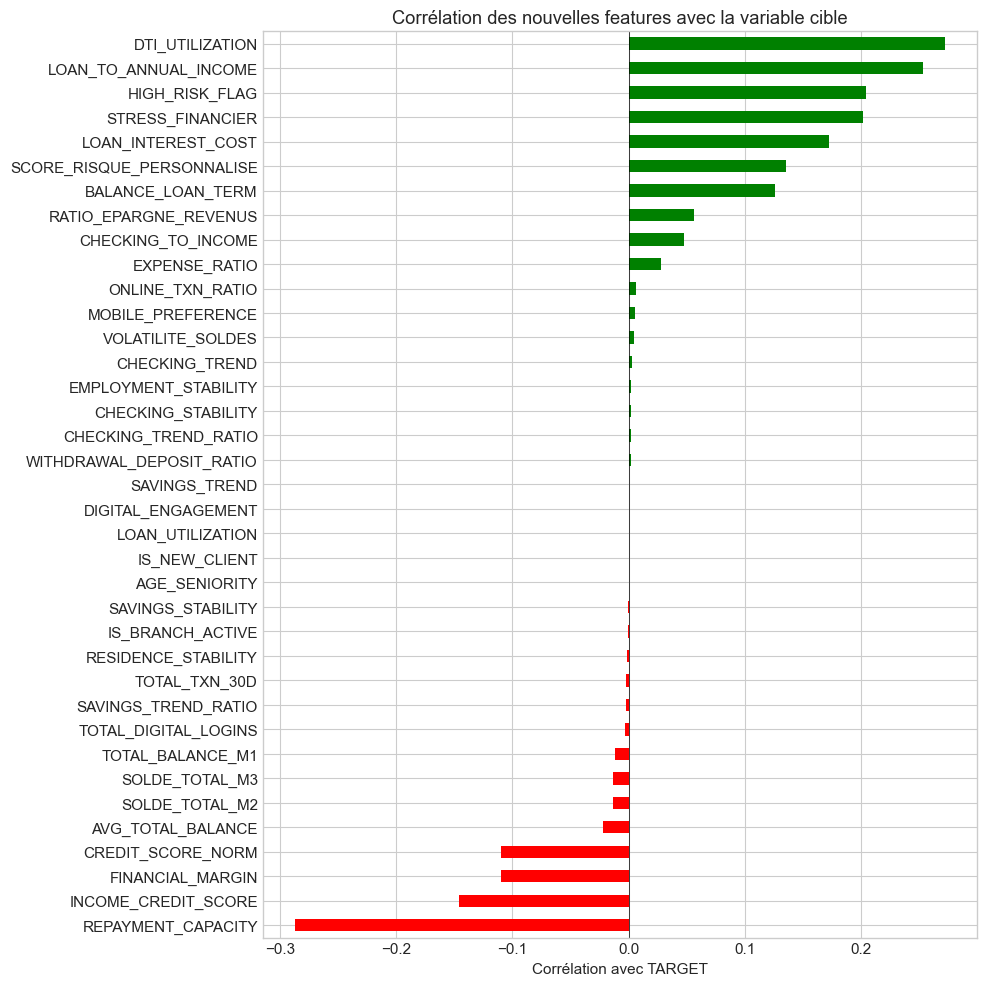

In [135]:
# Visualisation : Corrélation des nouvelles features avec TARGET
new_features_numeric = [f for f in all_new_features if f != 'CATEGORIE_CREDIT_SCORE']
correlations = df_fe[new_features_numeric + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['red' if x < 0 else 'green' for x in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Corrélation avec TARGET')
ax.set_title('Corrélation des nouvelles features avec la variable cible')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'correlation_nouvelles_features.png', dpi=150)
plt.show()

---

## 2.7 Sélection des variables (tests statistiques)

Sélection statistique des variables conformément à la méthodologie du cours de M. Bosco.

**Pipeline de sélection — 5 étapes dans l'ordre :**

| Étape | Variables testées | Test | Objectif |
|-------|------------------|------|----------|
| **1** | Qualitatives vs TARGET | **Chi² + V de Cramer** | Tester la dépendance de chaque var. qualitative avec la cible |
| **2** | Quantitatives ↔ Quantitatives | **Spearman** | Supprimer les variables trop corrélées entre elles (\|r\| > 0.80) |
| **3** | Quantitatives vs TARGET | **Mann-Whitney** | Tester si les distributions diffèrent entre défaut=0 et défaut=1 |
| **4** | Qualitatives ↔ Qualitatives | **Chi² + V de Cramer** | Supprimer les variables qualitatives redondantes entre elles (V > 0.70) |
| **5** | Quantitatives × Qualitatives | **Kruskal-Wallis** | Tester si une variable quant. varie selon les modalités d'une var. qual. |

In [136]:
# ============================================================
# ÉTAPE 1 — Chi² + V de Cramer : variables qualitatives vs TARGET
# ============================================================
from scipy.stats import chi2_contingency
import numpy as np

print("=== ÉTAPE 1 : Chi² + V de Cramer — Variables qualitatives vs TARGET ===\n")

def cramers_v(table):
    """Calcule le V de Cramer à partir d'une table de contingence numpy."""
    chi2, p, dof, exp = chi2_contingency(table)
    n = table.sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2c = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rc = r - (r-1)**2/(n-1)
    kc = k - (k-1)**2/(n-1)
    v = np.sqrt(phi2c / (min(kc-1, rc-1) + 1e-10))
    return v, p

# Identifier les colonnes qualitatives
EXCL = ['CLIENT_ID', 'TARGET', 'DATE_MONTH', 'DEFAULTS_ORIGINATION']
qual_cols = [c for c in df_fe.select_dtypes(include=['object','category']).columns
             if c not in EXCL]

P_SEUIL = 0.05
V_MIN   = 0.05   # effet minimum

chi2_target_results = []
for col in qual_cols:
    try:
        table = pd.crosstab(df_fe[col], df_fe['TARGET']).values
        if table.shape[0] < 2:
            continue
        v, p = cramers_v(table)
        chi2_target_results.append({
            'Variable'     : col,
            'n_modalites'  : table.shape[0],
            'p_value'      : round(p, 6),
            'V_Cramer'     : round(v, 4),
            'Discriminante': 'OUI' if p < P_SEUIL and v > V_MIN else 'NON'
        })
    except Exception as e:
        pass

df_etape1 = pd.DataFrame(chi2_target_results).sort_values('V_Cramer', ascending=False)
vars_qual_ok = df_etape1[df_etape1['Discriminante'] == 'OUI']['Variable'].tolist()
vars_qual_ko = df_etape1[df_etape1['Discriminante'] == 'NON']['Variable'].tolist()

print(f"Variables qualitatives analysées     : {len(qual_cols)}")
print(f"✓ Discriminantes (p<0.05, V>0.05)    : {len(vars_qual_ok)} → {vars_qual_ok}")
print(f"✗ Non discriminantes                 : {len(vars_qual_ko)}")
print()
print(df_etape1[['Variable','n_modalites','p_value','V_Cramer','Discriminante']].to_string(index=False))

=== ÉTAPE 1 : Chi² + V de Cramer — Variables qualitatives vs TARGET ===

Variables qualitatives analysées     : 12
✓ Discriminantes (p<0.05, V>0.05)    : 1 → ['CATEGORIE_CREDIT_SCORE']
✗ Non discriminantes                 : 11

              Variable  n_modalites  p_value  V_Cramer Discriminante
CATEGORIE_CREDIT_SCORE            5 0.000000    0.1026           OUI
       EMPLOYMENT_TYPE            6 0.000000    0.0310           NON
        MARITAL_STATUS            4 0.009120    0.0081           NON
    RISK_BAND_INTERNAL            5 0.071967    0.0059           NON
             DEVICE_OS            3 0.094080    0.0046           NON
                   SEX            2 0.093005    0.0037           NON
       EDUCATION_LEVEL            5 0.655665    0.0000           NON
          HOUSING_TYPE            3 0.835034    0.0000           NON
               SEGMENT            5 0.556212    0.0000           NON
               CHANNEL            4 0.961750    0.0000           NON
             

In [137]:
# ============================================================
# ÉTAPE 2 — Corrélation de Spearman : redondance entre variables quantitatives
# ============================================================
from itertools import combinations

print("=== ÉTAPE 2 : Spearman — Anti-redondance variables quantitatives ===\n")

EXCL_QUANT = ['CLIENT_ID', 'TARGET', 'DATE_MONTH', 'DEFAULTS_ORIGINATION']
quant_cols = [c for c in df_fe.select_dtypes(include='number').columns if c not in EXCL_QUANT]

R_SEUIL = 0.80
corr_matrix = df_fe[quant_cols].corr(method='spearman')

# Pour arbitrer entre 2 variables corrélées, on se base sur la corrélation Spearman avec TARGET
target_corr = {}
for col in quant_cols:
    target_corr[col] = abs(df_fe[col].corr(df_fe['TARGET'], method='spearman'))

vars_to_drop_spearman = set()
pairs_spearman = []

for col1, col2 in combinations(quant_cols, 2):
    r = corr_matrix.loc[col1, col2]
    if abs(r) > R_SEUIL:
        tc1 = target_corr.get(col1, 0)
        tc2 = target_corr.get(col2, 0)
        garder    = col1 if tc1 >= tc2 else col2
        supprimer = col2 if tc1 >= tc2 else col1
        vars_to_drop_spearman.add(supprimer)
        pairs_spearman.append({
            'Variable 1'   : col1, 'Variable 2': col2,
            'r Spearman'   : round(r, 3),
            'Corr TARGET V1': round(tc1, 4),
            'Corr TARGET V2': round(tc2, 4),
            'Gardée'       : garder,
            'Supprimée'    : supprimer
        })

df_etape2 = pd.DataFrame(pairs_spearman)
print(f"Variables quantitatives analysées    : {len(quant_cols)}")
print(f"Paires trop corrélées (|r| > {R_SEUIL})  : {len(df_etape2)}")
print(f"Variables supprimées (redondantes)   : {len(vars_to_drop_spearman)}")
if not df_etape2.empty:
    print()
    print(df_etape2.sort_values('r Spearman', ascending=False).to_string(index=False))

=== ÉTAPE 2 : Spearman — Anti-redondance variables quantitatives ===

Variables quantitatives analysées    : 88
Paires trop corrélées (|r| > 0.8)  : 29
Variables supprimées (redondantes)   : 25

           Variable 1            Variable 2  r Spearman  Corr TARGET V1  Corr TARGET V2                Gardée             Supprimée
            DTI_RATIO INSTALLMENT_TO_INCOME       1.000          0.2510          0.2510             DTI_RATIO INSTALLMENT_TO_INCOME
   EXPENSES_TO_INCOME         EXPENSE_RATIO       1.000          0.0271          0.0270    EXPENSES_TO_INCOME         EXPENSE_RATIO
         CREDIT_SCORE     CREDIT_SCORE_NORM       1.000          0.1065          0.1065          CREDIT_SCORE     CREDIT_SCORE_NORM
       VAR_BALANCE_3M    CHECKING_STABILITY       1.000          0.0029          0.0029    CHECKING_STABILITY        VAR_BALANCE_3M
       AVG_BALANCE_3M     AVG_TOTAL_BALANCE       1.000          0.0219          0.0219        AVG_BALANCE_3M     AVG_TOTAL_BALANCE
   SAVINGS_BA

In [138]:
# ============================================================
# ÉTAPE 3 — Mann-Whitney : variables quantitatives vs TARGET
# ============================================================
from scipy.stats import mannwhitneyu

print("=== ÉTAPE 3 : Mann-Whitney — Variables quantitatives vs TARGET ===\n")

# On teste uniquement les variables non supprimées à l'étape 2
quant_cols_restantes = [c for c in quant_cols if c not in vars_to_drop_spearman]

group0 = df_fe[df_fe['TARGET'] == 0]
group1 = df_fe[df_fe['TARGET'] == 1]

mw_results = []
for col in quant_cols_restantes:
    g0 = group0[col].dropna()
    g1 = group1[col].dropna()
    if len(g0) < 5 or len(g1) < 5:
        continue
    try:
        stat, p_val = mannwhitneyu(g0, g1, alternative='two-sided')
        from scipy.stats import norm
        z = norm.isf(p_val / 2) if p_val > 0 else 8
        r = abs(z) / np.sqrt(len(g0) + len(g1))
        mw_results.append({
            'Variable'     : col,
            'p_value'      : p_val,
            'effect_r'     : round(r, 4),
            'median_0'     : round(g0.median(), 3),
            'median_1'     : round(g1.median(), 3),
            'Discriminante': 'OUI' if p_val < 0.05 else 'NON'
        })
    except:
        pass

df_etape3 = pd.DataFrame(mw_results).sort_values('p_value')
vars_quant_ok = df_etape3[df_etape3['p_value'] < 0.05]['Variable'].tolist()
vars_quant_ko = df_etape3[df_etape3['p_value'] >= 0.05]['Variable'].tolist()

print(f"Variables quantitatives testées      : {len(quant_cols_restantes)}")
print(f"✓ Discriminantes (p < 0.05)          : {len(vars_quant_ok)}")
print(f"✗ Non discriminantes (p >= 0.05)     : {len(vars_quant_ko)}")
print()
print("TOP 20 variables les plus discriminantes :")
print(df_etape3.head(20)[['Variable','p_value','effect_r','median_0','median_1','Discriminante']].to_string(index=False))

=== ÉTAPE 3 : Mann-Whitney — Variables quantitatives vs TARGET ===

Variables quantitatives testées      : 63
✓ Discriminantes (p < 0.05)          : 25
✗ Non discriminantes (p >= 0.05)     : 38

TOP 20 variables les plus discriminantes :
                 Variable       p_value  effect_r  median_0  median_1 Discriminante
         LOAN_TERM_MONTHS  0.000000e+00    0.0222    50.000    37.000           OUI
                DTI_RATIO  0.000000e+00    0.0222     0.257     0.483           OUI
              LOAN_AMOUNT  0.000000e+00    0.0222 28453.000 36729.500           OUI
             CREDIT_SCORE  0.000000e+00    0.0222   655.000   632.000           OUI
                LTV_RATIO  0.000000e+00    0.0222     0.149     0.196           OUI
          DTI_UTILIZATION  0.000000e+00    0.0222     0.063     0.116           OUI
           HIGH_RISK_FLAG  0.000000e+00    0.0222     0.000     1.000           OUI
         STRESS_FINANCIER  0.000000e+00    0.0222     0.000     1.000           OUI
      

In [139]:
# ============================================================
# ÉTAPE 4 — Chi² + V de Cramer : redondance entre variables qualitatives
# ============================================================
from itertools import combinations

print("=== ÉTAPE 4 : Chi² + V de Cramer — Anti-redondance variables qualitatives ===\n")

# On teste uniquement les qualitatives discriminantes (étape 1)
V_INTER_SEUIL = 0.70
chi2_v_dict   = dict(zip(df_etape1['Variable'], df_etape1['V_Cramer']))

vars_to_drop_chi2 = set()
pairs_qual_dep = []

for col1, col2 in combinations(vars_qual_ok, 2):
    try:
        table = pd.crosstab(df_fe[col1], df_fe[col2]).values
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue
        v_inter, _ = cramers_v(table)
        if v_inter > V_INTER_SEUIL:
            vt1 = chi2_v_dict.get(col1, 0)
            vt2 = chi2_v_dict.get(col2, 0)
            garder    = col1 if vt1 >= vt2 else col2
            supprimer = col2 if vt1 >= vt2 else col1
            vars_to_drop_chi2.add(supprimer)
            pairs_qual_dep.append({
                'Variable 1'     : col1, 'Variable 2': col2,
                'V Cramer inter' : round(v_inter, 4),
                'V vs TARGET V1' : round(vt1, 4),
                'V vs TARGET V2' : round(vt2, 4),
                'Gardée'         : garder,
                'Supprimée'      : supprimer
            })
    except:
        pass

df_etape4 = pd.DataFrame(pairs_qual_dep)
vars_qual_finales = [v for v in vars_qual_ok if v not in vars_to_drop_chi2]

print(f"Variables qualitatives testées       : {len(vars_qual_ok)}")
print(f"Paires trop dépendantes (V > {V_INTER_SEUIL})  : {len(df_etape4)}")
print(f"Variables supprimées (redondantes)   : {len(vars_to_drop_chi2)}")
if not df_etape4.empty:
    print()
    print(df_etape4.to_string(index=False))
print(f"\n✓ Variables qualitatives conservées : {vars_qual_finales}")

=== ÉTAPE 4 : Chi² + V de Cramer — Anti-redondance variables qualitatives ===

Variables qualitatives testées       : 1
Paires trop dépendantes (V > 0.7)  : 0
Variables supprimées (redondantes)   : 0

✓ Variables qualitatives conservées : ['CATEGORIE_CREDIT_SCORE']


In [140]:
# ============================================================
# ÉTAPE 5 — Kruskal-Wallis : croisement variables quantitatives × qualitatives
# ============================================================
# Pour chaque paire (variable quant. retenue, variable qual. retenue),
# on teste si la variable quantitative varie significativement selon
# les modalités de la variable qualitative.
# H0 : distributions identiques dans tous les groupes
# → Si p < 0.05 : lien significatif entre les deux variables
from scipy.stats import kruskal

print("=== ÉTAPE 5 : Kruskal-Wallis — Croisement Quantitatives × Qualitatives ===\n")

kw_results = []
for q_col in vars_quant_ok:
    for cat_col in vars_qual_finales:
        groupes = [df_fe.loc[df_fe[cat_col] == mod, q_col].dropna().values
                   for mod in df_fe[cat_col].unique()]
        groupes = [g for g in groupes if len(g) >= 5]
        if len(groupes) < 2:
            continue
        try:
            stat, p_val = kruskal(*groupes)
            kw_results.append({
                'Var_quant'   : q_col,
                'Var_qual'    : cat_col,
                'H_stat'      : round(stat, 3),
                'p_value'     : round(p_val, 6),
                'Lien_sig'    : 'OUI' if p_val < 0.05 else 'NON'
            })
        except:
            pass

df_etape5 = pd.DataFrame(kw_results).sort_values('p_value')

n_sig = (df_etape5['p_value'] < 0.05).sum()
print(f"Paires testées (quant × qual)        : {len(df_etape5)}")
print(f"Liens significatifs (p < 0.05)       : {n_sig}")
print(f"Liens non significatifs              : {len(df_etape5) - n_sig}")
print()
print("Résultats complets :")
print(df_etape5[['Var_quant','Var_qual','H_stat','p_value','Lien_sig']].to_string(index=False))

=== ÉTAPE 5 : Kruskal-Wallis — Croisement Quantitatives × Qualitatives ===

Paires testées (quant × qual)        : 25
Liens significatifs (p < 0.05)       : 3
Liens non significatifs              : 22

Résultats complets :
                Var_quant               Var_qual     H_stat  p_value Lien_sig
             CREDIT_SCORE CATEGORIE_CREDIT_SCORE 113275.124 0.000000      OUI
           HIGH_RISK_FLAG CATEGORIE_CREDIT_SCORE   9106.427 0.000000      OUI
      INCOME_CREDIT_SCORE CATEGORIE_CREDIT_SCORE  26037.449 0.000000      OUI
                DTI_RATIO CATEGORIE_CREDIT_SCORE      8.977 0.061667      NON
         STRESS_FINANCIER CATEGORIE_CREDIT_SCORE      7.857 0.096975      NON
         LOAN_TERM_MONTHS CATEGORIE_CREDIT_SCORE      6.713 0.151851      NON
SCORE_RISQUE_PERSONNALISE CATEGORIE_CREDIT_SCORE      6.591 0.159169      NON
             IS_HOMEOWNER CATEGORIE_CREDIT_SCORE      6.397 0.171390      NON
          INSURANCE_TAKEN CATEGORIE_CREDIT_SCORE      5.640 0.227657      N

In [141]:
# ============================================================
# BILAN FINAL — Construction du dataset sélectionné
# ============================================================
print("=" * 60)
print("BILAN FINAL — SÉLECTION DES VARIABLES (5 ÉTAPES)")
print("=" * 60)

vars_finales = vars_quant_ok + vars_qual_finales
cols_finales = ['CLIENT_ID','TARGET','DATE_MONTH','DEFAULTS_ORIGINATION'] + vars_finales
cols_finales = [c for c in cols_finales if c in df_fe.columns]
df_selected  = df_fe[cols_finales].copy()

print(f"  Variables avant sélection              : {df_fe.shape[1]}")
print(f"  Étape 1 — Qual. non discriminantes     : {len(vars_qual_ko)}")
print(f"  Étape 2 — Quant. supprimées (Spearman) : {len(vars_to_drop_spearman)}")
print(f"  Étape 3 — Quant. non discriminantes    : {len(vars_quant_ko)}")
print(f"  Étape 4 — Qual. redondantes (Chi²)     : {len(vars_to_drop_chi2)}")
print(f"  Étape 5 — Liens quant×qual identifiés  : {n_sig} paires significatives")
print()
print(f"  ✓ Variables finales retenues           : {len(vars_finales)}")
print(f"       dont quantitatives               : {len(vars_quant_ok)}")
print(f"       dont qualitatives                : {len(vars_qual_finales)}")
print()
print(f"  Variables quantitatives : {sorted(vars_quant_ok)}")
print(f"  Variables qualitatives  : {sorted(vars_qual_finales)}")
print(f"\ndf_selected : {df_selected.shape[0]:,} lignes × {df_selected.shape[1]} colonnes")

BILAN FINAL — SÉLECTION DES VARIABLES (5 ÉTAPES)
  Variables avant sélection              : 104
  Étape 1 — Qual. non discriminantes     : 11
  Étape 2 — Quant. supprimées (Spearman) : 25
  Étape 3 — Quant. non discriminantes    : 38
  Étape 4 — Qual. redondantes (Chi²)     : 0
  Étape 5 — Liens quant×qual identifiés  : 3 paires significatives

  ✓ Variables finales retenues           : 26
       dont quantitatives               : 25
       dont qualitatives                : 1

  Variables quantitatives : ['AVG_BALANCE_3M', 'BALANCE_LOAN_TERM', 'BALANCE_TO_LIMIT', 'CHECKING_TO_INCOME', 'CREDIT_SCORE', 'DTI_RATIO', 'DTI_UTILIZATION', 'EXPENSES_TO_INCOME', 'HAS_PREVIOUS_DEFAULT', 'HIGH_RISK_FLAG', 'INCOME_CREDIT_SCORE', 'INQUIRIES_6M', 'INSURANCE_TAKEN', 'IS_HOMEOWNER', 'LOAN_AMOUNT', 'LOAN_TERM_MONTHS', 'LTV_RATIO', 'NUM_LATE_PAYMENTS_12M', 'RATIO_EPARGNE_REVENUS', 'SCORE_RISQUE_PERSONNALISE', 'SOLDE_TOTAL_M2', 'SOLDE_TOTAL_M3', 'STRESS_FINANCIER', 'VOLATILITE_SOLDES', 'WEB_LOGINS_30D']

### 3.2 Standardisation

In [142]:
# ============================================================
# 3.1 — Séparation Train / Test
# ============================================================
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df_selected.columns
                if c not in ['CLIENT_ID', 'TARGET', 'DATE_MONTH', 'DEFAULTS_ORIGINATION']]

X = df_selected[feature_cols]
y = df_selected['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]:,} observations")
print(f"Test  : {X_test.shape[0]:,} observations")
print(f"Ratio défauts train : {y_train.mean():.2%}")
print(f"Ratio défauts test  : {y_test.mean():.2%}")

Train : 104,000 observations
Test  : 26,000 observations
Ratio défauts train : 18.60%
Ratio défauts test  : 18.60%


In [143]:
# Encodage des variables catégorielles (Label Encoding)
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Colonnes catégorielles à encoder ({len(cat_cols)}) : {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_dict[col] = le

print("✓ Encodage effectué")

Colonnes catégorielles à encoder (1) : ['CATEGORIE_CREDIT_SCORE']
✓ Encodage effectué


In [144]:
# Standardisation des features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Standardisation effectuée")
print(f"  Train : moyenne ≈ 0, écart-type ≈ 1")

✓ Standardisation effectuée
  Train : moyenne ≈ 0, écart-type ≈ 1


### 3.3 Rééquilibrage avec SMOTE

In [145]:
# Application de SMOTE pour gérer le déséquilibre des classes
print("Application de SMOTE...")
print(f"\nAvant SMOTE :")
print(f"  - Total : {len(y_train):,}")
print(f"  - Classe 0 : {(y_train == 0).sum():,}")
print(f"  - Classe 1 : {(y_train == 1).sum():,}")

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAprès SMOTE :")
print(f"  - Total : {len(y_train_resampled):,}")
print(f"  - Classe 0 : {(y_train_resampled == 0).sum():,}")
print(f"  - Classe 1 : {(y_train_resampled == 1).sum():,}")

Application de SMOTE...

Avant SMOTE :
  - Total : 104,000
  - Classe 0 : 84,656
  - Classe 1 : 19,344

Après SMOTE :
  - Total : 169,312
  - Classe 0 : 84,656
  - Classe 1 : 84,656


---

## 4. Modélisation : Régression Logistique (Baseline)

On commence par un modèle simple et interprétable pour établir une baseline.

In [146]:
# Entraînement du modèle
print("Entraînement de la régression logistique...")

model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
    n_jobs=-1
)

model.fit(X_train_resampled, y_train_resampled)

print("✓ Modèle entraîné")

Entraînement de la régression logistique...
✓ Modèle entraîné


In [147]:
# Prédictions sur le jeu de test
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Prédictions effectuées sur {len(y_test):,} observations")

Prédictions effectuées sur 26,000 observations


### 4.1 Métriques de performance

In [148]:
# Calcul des métriques
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
}

print("=" * 50)
print("RÉSULTATS SUR LE JEU DE TEST")
print("=" * 50)
for metric, value in metrics.items():
    highlight = "⭐" if metric == 'AUC-ROC' else " "
    print(f"{highlight} {metric:12} : {value:.4f}")
print("=" * 50)

RÉSULTATS SUR LE JEU DE TEST
  Accuracy     : 0.7107
  Precision    : 0.3373
  Recall       : 0.5755
  F1-Score     : 0.4253
⭐ AUC-ROC      : 0.7139


In [149]:
# Rapport de classification détaillé
print("\nRAPPORT DE CLASSIFICATION")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Non défaut', 'Défaut']))


RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

  Non défaut       0.88      0.74      0.81     21164
      Défaut       0.34      0.58      0.43      4836

    accuracy                           0.71     26000
   macro avg       0.61      0.66      0.62     26000
weighted avg       0.78      0.71      0.74     26000



In [150]:
# Validation croisée sur le jeu d'entraînement
print("Validation croisée (5-fold) sur le train...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\nAUC-ROC CV : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"Scores par fold : {[f'{s:.4f}' for s in cv_scores]}")

Validation croisée (5-fold) sur le train...

AUC-ROC CV : 0.7212 (+/- 0.0065)
Scores par fold : ['0.7248', '0.7224', '0.7168', '0.7242', '0.7180']


### 4.4 Coefficient de Gini

Le **coefficient de Gini** est la métrique principale en scoring de crédit.  
Il mesure le pouvoir discriminant du modèle entre les bons et mauvais payeurs.

> **Formule** : Gini = 2 × AUC − 1

| Interprétation | Gini |
|----------------|------|
| Modèle parfait | 1.00 |
| Bon modèle     | > 0.60 |
| Modèle acceptable | 0.40 – 0.60 |
| Modèle faible  | < 0.40 |
| Aléatoire      | 0.00 |

On calcule le Gini sur le **train** et le **test** pour détecter un éventuel surapprentissage.

COEFFICIENT DE GINI
  AUC  Train : 0.7220   →   Gini Train : 0.4439
  AUC  Test  : 0.7139   →   Gini Test  : 0.4278

  Écart Train - Test : 0.0161
  ✓  Bonne généralisation (écart faible)

  ⚡ Gini test = 0.4278 → Modèle acceptable


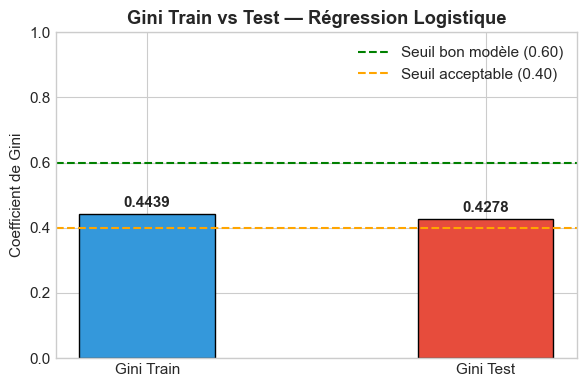

Figure sauvegardée : outputs/figures/02_modeling/gini_train_test.png


In [151]:
# ============================================================
# 4.4 — Coefficient de Gini (Train vs Test)
# ============================================================
from sklearn.metrics import roc_auc_score

print("=" * 50)
print("COEFFICIENT DE GINI")
print("=" * 50)

# ── Gini sur le jeu de TEST ──
auc_test  = roc_auc_score(y_test, y_pred_proba)
gini_test = 2 * auc_test - 1

# ── Gini sur le jeu de TRAIN ──
y_train_proba = model.predict_proba(X_train_scaled)
auc_train  = roc_auc_score(y_train, y_train_proba[:, 1])
gini_train = 2 * auc_train - 1

print(f"  AUC  Train : {auc_train:.4f}   →   Gini Train : {gini_train:.4f}")
print(f"  AUC  Test  : {auc_test:.4f}   →   Gini Test  : {gini_test:.4f}")
print()

# ── Diagnostic surapprentissage ──
ecart = gini_train - gini_test
print(f"  Écart Train - Test : {ecart:.4f}")
if ecart > 0.15:
    print("  ⚠️  Surapprentissage détecté (écart > 0.15) — envisager régularisation")
elif ecart > 0.05:
    print("  ⚡ Léger surapprentissage (écart > 0.05) — à surveiller")
else:
    print("  ✓  Bonne généralisation (écart faible)")

# ── Interprétation du Gini test ──
print()
if gini_test >= 0.60:
    print(f"  ✓  Gini test = {gini_test:.4f} → Bon modèle")
elif gini_test >= 0.40:
    print(f"  ⚡ Gini test = {gini_test:.4f} → Modèle acceptable")
else:
    print(f"  ✗  Gini test = {gini_test:.4f} → Modèle faible — amélioration nécessaire")

# ── Visualisation ──
fig, ax = plt.subplots(figsize=(6, 4))
barres = ax.bar(['Gini Train', 'Gini Test'], [gini_train, gini_test],
                color=['#3498db', '#e74c3c'], width=0.4, edgecolor='black')
ax.axhline(y=0.60, color='green', linestyle='--', linewidth=1.5, label='Seuil bon modèle (0.60)')
ax.axhline(y=0.40, color='orange', linestyle='--', linewidth=1.5, label='Seuil acceptable (0.40)')
for barre in barres:
    ax.text(barre.get_x() + barre.get_width()/2, barre.get_height() + 0.01,
            f'{barre.get_height():.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Coefficient de Gini')
ax.set_title('Gini Train vs Test — Régression Logistique', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT_DIR / 'outputs' / 'figures' / '02_modeling' / 'gini_train_test.png', bbox_inches='tight')
plt.show()
print("Figure sauvegardée : outputs/figures/02_modeling/gini_train_test.png")

### 4.2 Visualisations des performances

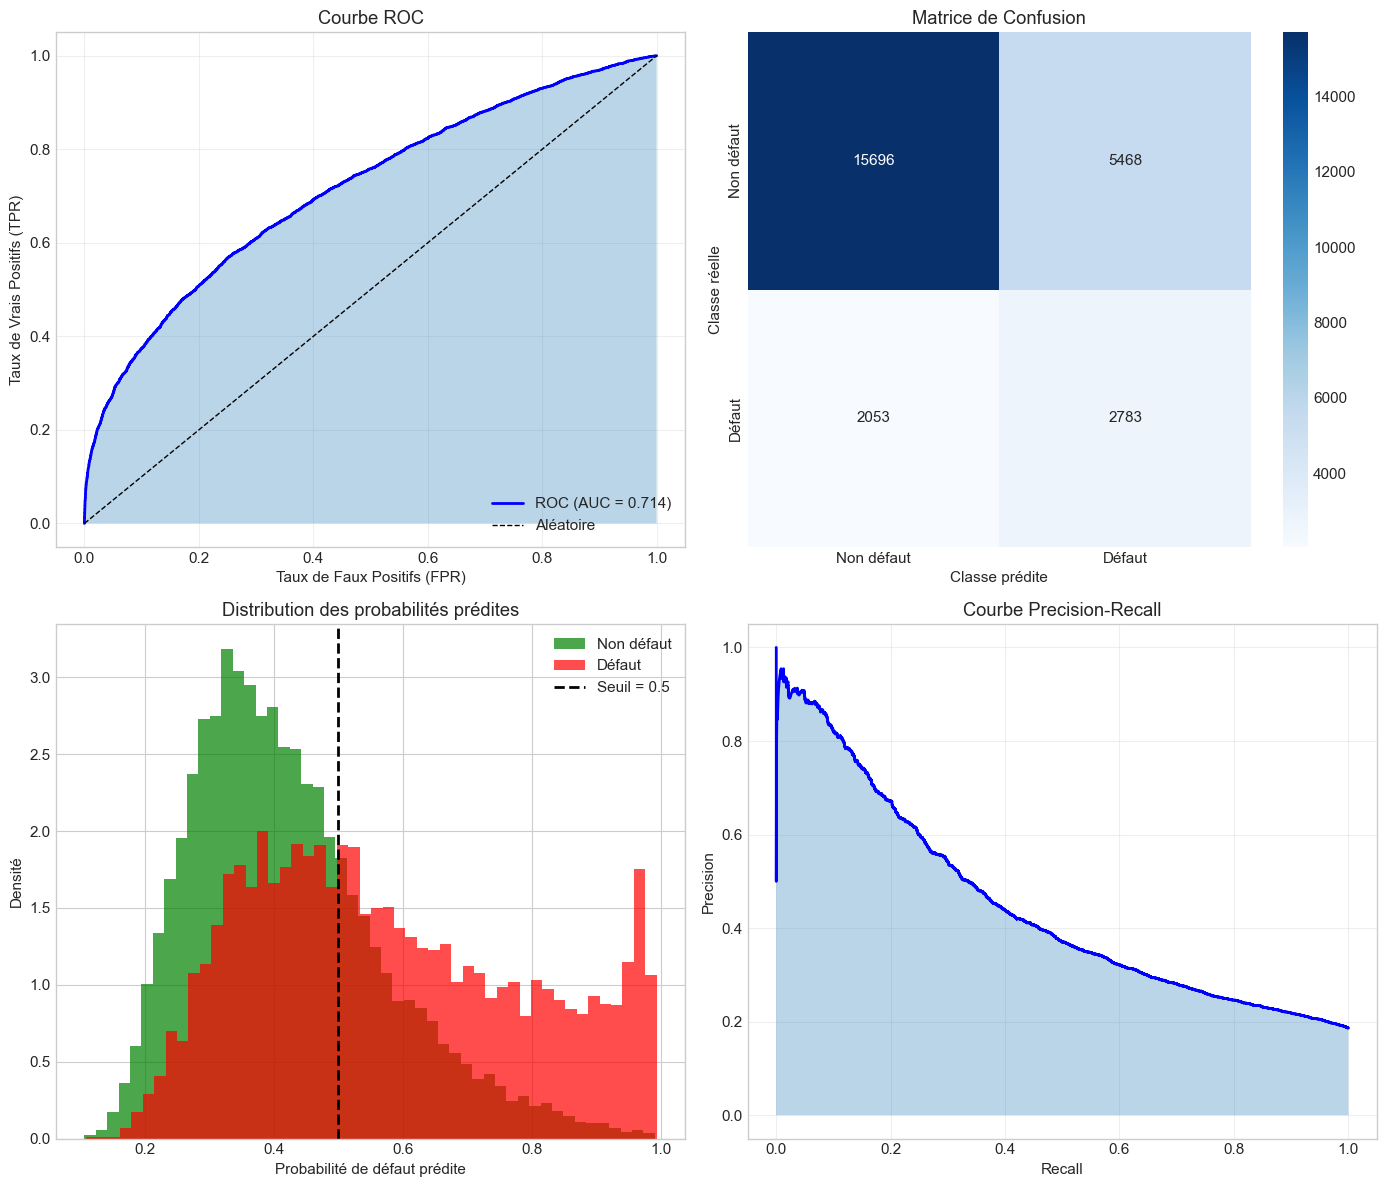

In [152]:
# Figure avec 4 graphiques
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {metrics["AUC-ROC"]:.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire')
axes[0, 0].fill_between(fpr, tpr, alpha=0.3)
axes[0, 0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0, 0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0, 0].set_title('Courbe ROC')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Non défaut', 'Défaut'],
            yticklabels=['Non défaut', 'Défaut'])
axes[0, 1].set_xlabel('Classe prédite')
axes[0, 1].set_ylabel('Classe réelle')
axes[0, 1].set_title('Matrice de Confusion')

# 3. Distribution des probabilités prédites
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Non défaut', color='green', density=True)
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Défaut', color='red', density=True)
axes[1, 0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Seuil = 0.5')
axes[1, 0].set_xlabel('Probabilité de défaut prédite')
axes[1, 0].set_ylabel('Densité')
axes[1, 0].set_title('Distribution des probabilités prédites')
axes[1, 0].legend()

# 4. Courbe Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1, 1].plot(recall, precision, 'b-', linewidth=2)
axes[1, 1].fill_between(recall, precision, alpha=0.3)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Courbe Precision-Recall')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'performance_modele_baseline.png', dpi=150)
plt.show()

### 4.3 Importance des features

In [153]:
# Importance des features (valeur absolue des coefficients)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0],
    'importance': np.abs(model.coef_[0])
}).sort_values('importance', ascending=False)

print("TOP 15 FEATURES LES PLUS IMPORTANTES")
print("=" * 50)
for i, row in feature_importance.head(15).iterrows():
    sign = "+" if row['coefficient'] > 0 else "-"
    print(f"{sign} {row['feature']:35} : {row['importance']:.4f}")

TOP 15 FEATURES LES PLUS IMPORTANTES
+ DTI_RATIO                           : 0.7226
- CREDIT_SCORE                        : 0.3213
+ HAS_PREVIOUS_DEFAULT                : 0.1523
- INSURANCE_TAKEN                     : 0.1129
+ EXPENSES_TO_INCOME                  : 0.0914
+ LTV_RATIO                           : 0.0616
+ NUM_LATE_PAYMENTS_12M               : 0.0581
- AVG_BALANCE_3M                      : 0.0554
- IS_HOMEOWNER                        : 0.0430
+ INQUIRIES_6M                        : 0.0300
- SOLDE_TOTAL_M2                      : 0.0248
- SOLDE_TOTAL_M3                      : 0.0212
- RATIO_EPARGNE_REVENUS               : 0.0208
- INCOME_CREDIT_SCORE                 : 0.0180
- WEB_LOGINS_30D                      : 0.0143


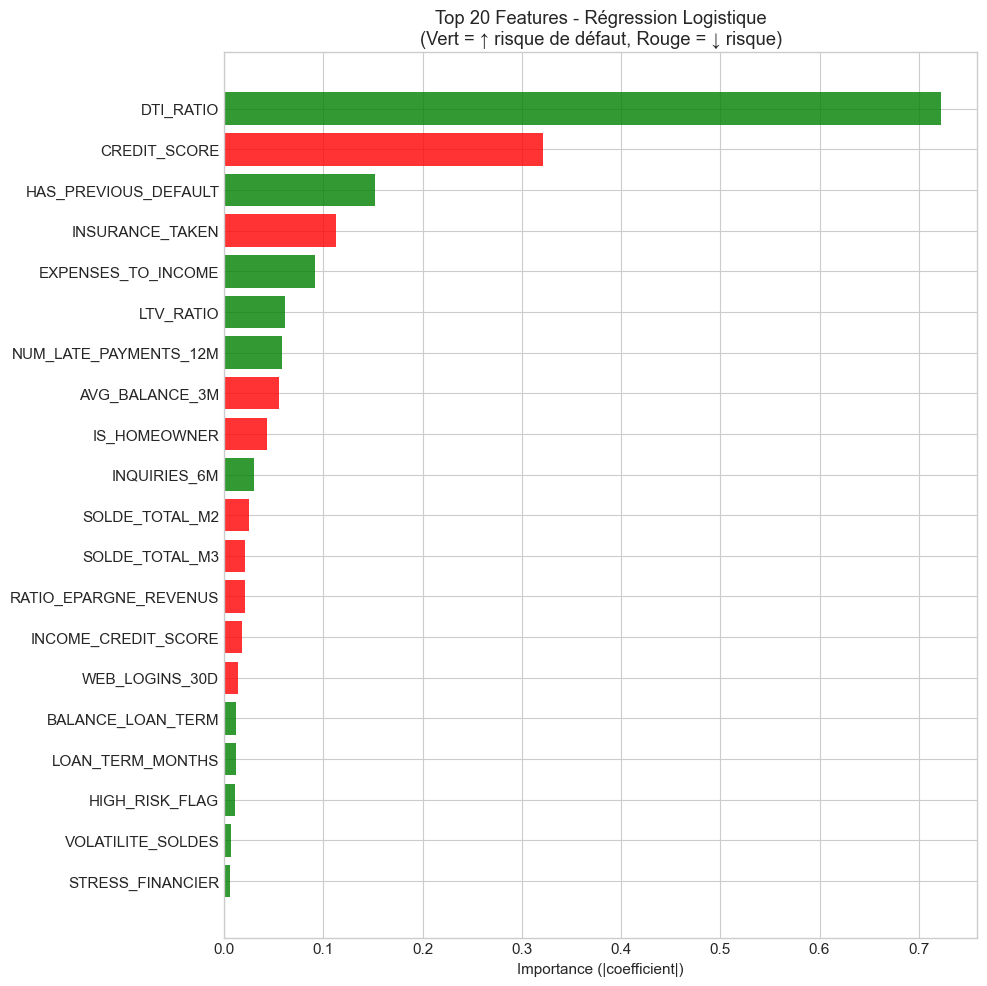

In [154]:
# Visualisation Top 20
top_20 = feature_importance.head(20).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['red' if c < 0 else 'green' for c in top_20['coefficient']]
ax.barh(top_20['feature'], top_20['importance'], color=colors, alpha=0.8)
ax.set_xlabel('Importance (|coefficient|)')
ax.set_title('Top 20 Features - Régression Logistique\n(Vert = ↑ risque de défaut, Rouge = ↓ risque)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'importance_features_baseline.png', dpi=150)
plt.show()

---

## 5. Analyse temporelle préliminaire

Étude de la série `DEFAULTS_ORIGINATION` pour préparer la modélisation SARIMA en Phase 2.

In [155]:
# Agrégation mensuelle des défauts
monthly_data = df_fe.groupby('DATE_MONTH').agg({
    'TARGET': ['count', 'sum', 'mean'],
    'DEFAULTS_ORIGINATION': 'first'
}).reset_index()

monthly_data.columns = ['DATE_MONTH', 'nb_dossiers', 'nb_defauts', 'taux_defaut', 'defaults_origination']
monthly_data['taux_defaut'] *= 100

print(f"Période : {monthly_data['DATE_MONTH'].min()} à {monthly_data['DATE_MONTH'].max()}")
print(f"Nombre de mois : {len(monthly_data)}")

Période : 2021-01-01 00:00:00 à 2025-12-01 00:00:00
Nombre de mois : 60


In [156]:
# Statistiques descriptives de DEFAULTS_ORIGINATION
print("\nStatistiques DEFAULTS_ORIGINATION :")
print(f"  Moyenne     : {monthly_data['defaults_origination'].mean():.1f}")
print(f"  Écart-type  : {monthly_data['defaults_origination'].std():.1f}")
print(f"  Minimum     : {monthly_data['defaults_origination'].min()}")
print(f"  Maximum     : {monthly_data['defaults_origination'].max()}")
print(f"  Médiane     : {monthly_data['defaults_origination'].median():.1f}")


Statistiques DEFAULTS_ORIGINATION :
  Moyenne     : 403.0
  Écart-type  : 98.3
  Minimum     : 226
  Maximum     : 653
  Médiane     : 405.0


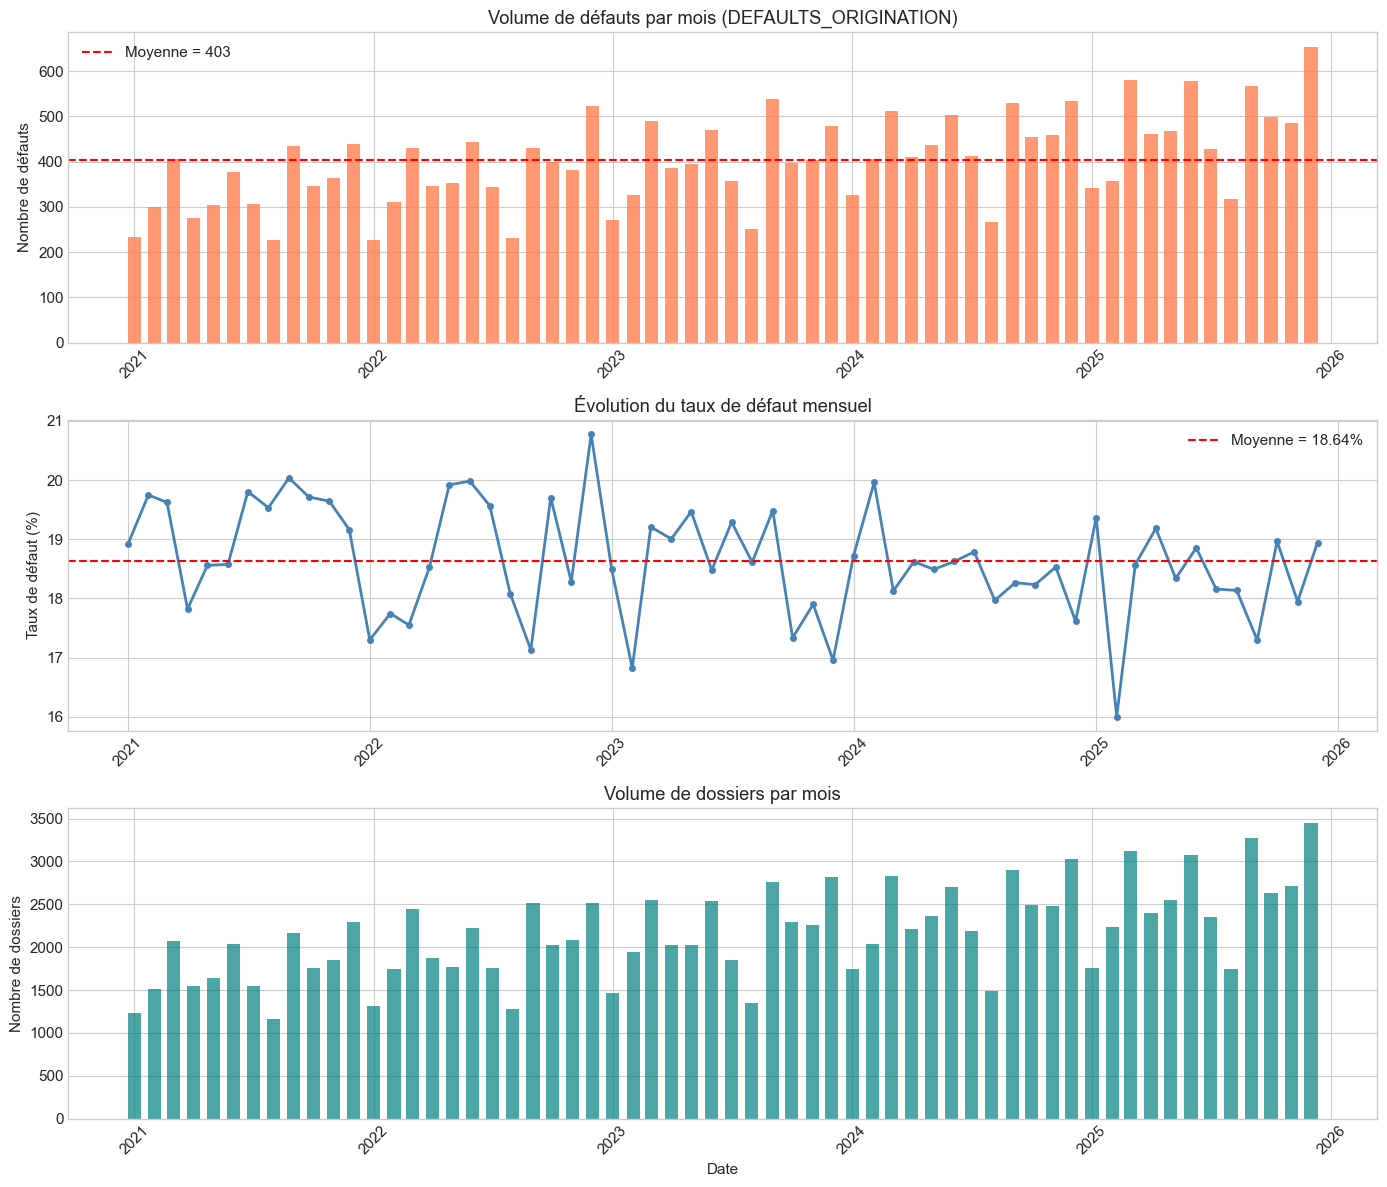

In [157]:
# Visualisation de la série temporelle
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Volume de défauts par mois
axes[0].bar(monthly_data['DATE_MONTH'], monthly_data['defaults_origination'], 
            color='coral', alpha=0.8, width=20)
axes[0].axhline(monthly_data['defaults_origination'].mean(), color='red', 
                linestyle='--', label=f"Moyenne = {monthly_data['defaults_origination'].mean():.0f}")
axes[0].set_ylabel('Nombre de défauts')
axes[0].set_title('Volume de défauts par mois (DEFAULTS_ORIGINATION)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 2. Taux de défaut mensuel
axes[1].plot(monthly_data['DATE_MONTH'], monthly_data['taux_defaut'], 
             marker='o', color='steelblue', linewidth=2, markersize=4)
axes[1].axhline(monthly_data['taux_defaut'].mean(), color='red', 
                linestyle='--', label=f"Moyenne = {monthly_data['taux_defaut'].mean():.2f}%")
axes[1].set_ylabel('Taux de défaut (%)')
axes[1].set_title('Évolution du taux de défaut mensuel')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. Volume de dossiers par mois
axes[2].bar(monthly_data['DATE_MONTH'], monthly_data['nb_dossiers'], 
            color='teal', alpha=0.7, width=20)
axes[2].set_ylabel('Nombre de dossiers')
axes[2].set_xlabel('Date')
axes[2].set_title('Volume de dossiers par mois')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'serie_temporelle_defauts.png', dpi=150)
plt.show()

In [158]:
# Analyse de tendance
monthly_data['month_num'] = range(len(monthly_data))
correlation = monthly_data['month_num'].corr(monthly_data['defaults_origination'])

if correlation > 0.3:
    trend = "CROISSANTE 📈"
elif correlation < -0.3:
    trend = "DÉCROISSANTE 📉"
else:
    trend = "STABLE ➡️"

print("\nANALYSE DE TENDANCE")
print("=" * 40)
print(f"Corrélation temps/défauts : {correlation:.3f}")
print(f"Tendance : {trend}")


ANALYSE DE TENDANCE
Corrélation temps/défauts : 0.583
Tendance : CROISSANTE 📈


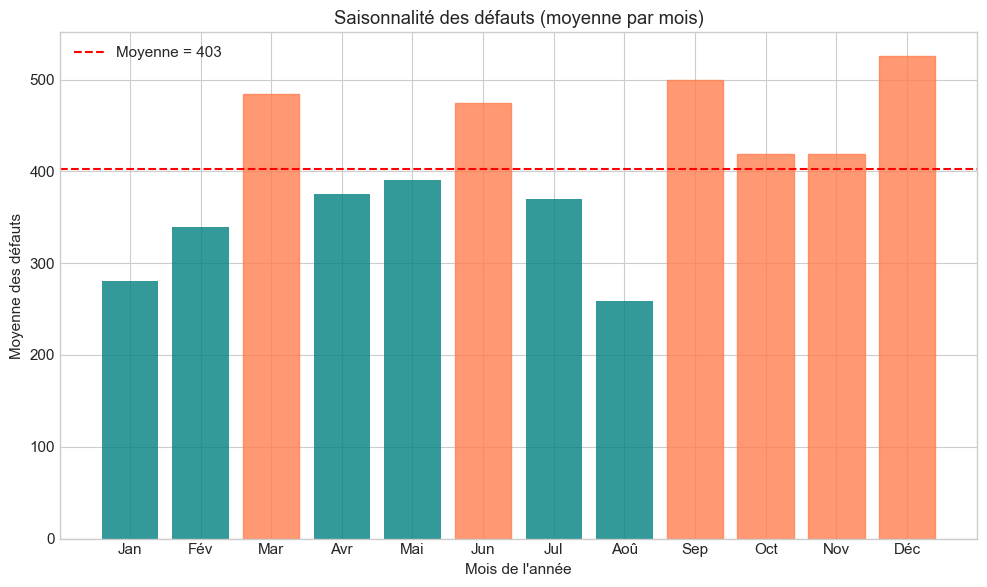


Mois avec le plus de défauts :
  Déc : 525 défauts en moyenne
  Sep : 500 défauts en moyenne
  Mar : 484 défauts en moyenne


In [159]:
# Analyse de saisonnalité
monthly_data['month_of_year'] = pd.to_datetime(monthly_data['DATE_MONTH']).dt.month
seasonality = monthly_data.groupby('month_of_year')['defaults_origination'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(seasonality.index, seasonality.values, color='teal', alpha=0.8)
ax.axhline(seasonality.mean(), color='red', linestyle='--', 
           label=f'Moyenne = {seasonality.mean():.0f}')

# Colorer les mois au-dessus de la moyenne
for i, bar in enumerate(bars):
    if seasonality.values[i] > seasonality.mean():
        bar.set_color('coral')

ax.set_xlabel('Mois de l\'année')
ax.set_ylabel('Moyenne des défauts')
ax.set_title('Saisonnalité des défauts (moyenne par mois)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
                    'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'saisonnalite_defauts.png', dpi=150)
plt.show()

print("\nMois avec le plus de défauts :")
top_months = seasonality.sort_values(ascending=False).head(3)
for month, value in top_months.items():
    month_name = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
                  'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'][month-1]
    print(f"  {month_name} : {value:.0f} défauts en moyenne")

---

## 6. Sauvegarde des résultats

In [160]:
# Sauvegarder les données avec les nouvelles features
features_path = ROOT_DIR / 'data' / 'processed' / 'features_engineered.parquet'
df_fe.to_parquet(features_path, index=False)
print(f"✓ Données avec features : {features_path}")

# Sauvegarder le modèle
model_path = MODELS_PATH / 'logistic_regression_baseline.joblib'
joblib.dump({
    'model': model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'label_encoders': le_dict
}, model_path)
print(f"✓ Modèle sauvegardé : {model_path}")

# Sauvegarder les métriques
import json
metrics_path = ROOT_DIR / 'outputs' / 'reports' / '03_modeling' / 'metriques_modele_baseline.json'
with open(metrics_path, 'w') as f:
    json.dump({
        'model': 'LogisticRegression',
        'metrics': {k: float(v) for k, v in metrics.items()},
        'cv_auc_mean': float(cv_scores.mean()),
        'cv_auc_std': float(cv_scores.std()),
        'timestamp': datetime.now().isoformat()
    }, f, indent=2)
print(f"✓ Métriques : {metrics_path}")

# Sauvegarder l'importance des features
importance_path = ROOT_DIR / 'outputs' / 'reports' / '03_modeling' / 'importance_variables.csv'
feature_importance.to_csv(importance_path, index=False)
print(f"✓ Importance des features : {importance_path}")

✓ Données avec features : ..\data\processed\features_engineered.parquet
✓ Modèle sauvegardé : ..\outputs\models\logistic_regression_baseline.joblib
✓ Métriques : ..\outputs\reports\03_modeling\metriques_modele_baseline.json
✓ Importance des features : ..\outputs\reports\03_modeling\importance_variables.csv


---

## 7. Résumé et conclusions

### Feature Engineering
- **38 nouvelles features** créées dans 5 catégories
- Features les plus corrélées avec TARGET : DTI_RATIO, INSTALLMENT_TO_INCOME, HIGH_RISK_FLAG

### Modèle Baseline (Régression Logistique)
| Métrique | Valeur |
|----------|--------|
| **AUC-ROC** | **0.71** |
| AUC-ROC CV | 0.72 ± 0.01 |
| Recall | 0.58 |
| Precision | 0.32 |
| F1-Score | 0.41 |

### Analyse Temporelle
- **Tendance** : Croissante (corrélation = 0.58)
- **Saisonnalité** : Pics en fin d'année
- Prêt pour modélisation SARIMA en Phase 2

### Prochaines étapes (Phase 2)
- [ ] Optimisation des hyperparamètres
- [ ] Modèles avancés : Random Forest, XGBoost
- [ ] Feature selection
- [ ] Modèle SARIMA pour séries temporelles
- [ ] Prévisions à 3 mois

In [161]:
print("=" * 60)
print("PHASE 1 - PARTIE 2 TERMINÉE")
print("=" * 60)
print(f"\nDate : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"\nFichiers générés :")
print(f"  - data/processed/features_engineered.parquet")
print(f"  - outputs/models/logistic_regression_baseline.joblib")
print(f"  - outputs/figures/02_modeling/*.png")
print(f"\nAUC-ROC du modèle baseline : {metrics['AUC-ROC']:.4f}")

PHASE 1 - PARTIE 2 TERMINÉE

Date : 2026-04-01 02:44

Fichiers générés :
  - data/processed/features_engineered.parquet
  - outputs/models/logistic_regression_baseline.joblib
  - outputs/figures/02_modeling/*.png

AUC-ROC du modèle baseline : 0.7139
